
<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Large Language Models </b><br><br>Computer Assignment 1</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Behzad Jannati / Sobhan Abedi - Final Project -
        <h1> 810103098 /810103081 </h1>
        <h1> Prof. Mohammad Javad Dousti & Yadoulah Yaghoubzadeh
    </div>
</div>

>[Enhancing Large Language Model Efficiency Through Layer Pruning and Speculative Decoding](#scrollTo=bgEv4XdicfKl)

>>[Libraries and Setup](#scrollTo=qOcpUTJsJtji)

>>[Define a class for Analyzing Pruning for the given Models:](#scrollTo=d6aCc4uKKKiP)

>>[Pruning and Layer Analysis for Qwen 2.5 7B:](#scrollTo=rNJ7y2PQhzm-)

>>[Qwen 3 8B Layer Pruning Analysis](#scrollTo=MTgSPOesSitj)

>>[LLAMA 3 Layer Pruning Analysis:](#scrollTo=69Wb90jCSUKR)



#Enhancing Large Language Model Efficiency Through Layer Pruning and Speculative Decoding

##Libraries and Setup

### Environment Setup
**Install Required Libraries**

In [ ]:
!pip install -r requirements.txt

In [1]:
!pip list

Package                   Version
------------------------- ------------
absl-py                   2.3.1
accelerate                1.9.0
aiohappyeyeballs          2.6.1
aiohttp                   3.12.15
aiosignal                 1.4.0
anyio                     4.7.0
argon2-cffi               21.3.0
argon2-cffi-bindings      21.2.0
asttokens                 3.0.0
async-lru                 2.0.4
attrs                     25.3.0
babel                     2.16.0
beautifulsoup4            4.13.4
bitsandbytes              0.46.1
bleach                    6.2.0
brotlicffi                1.0.9.2
certifi                   2025.7.14
cffi                      1.17.1
charset-normalizer        3.4.2
comm                      0.2.1
contourpy                 1.3.3
cycler                    0.12.1
datasets                  4.0.0
debugpy                   1.8.11
decorator                 5.1.1
defusedxml                0.7.1
dill                      0.3.8
executing                 0.8.3
fastjsonschema

**Backup installation (mostly for Google Colab)**

In [ ]:
# Install required libraries (Backup)
# !pip install -q transformers bitsandbytes accelerate peft
# !pip install -U datasets huggingface-hub fsspec


In [ ]:
# Select based on your system
# !git config --global credential.helper store
# !git config --global credential.helper manager

**Login To Huggingface**

In [1]:
# Import .env file into os env variables
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
!huggingface-cli login --token $HF_TOKEN --add-to-git-credential

/home/sobhan/anaconda3/envs/llm/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.
Token is valid (permission: write).
The token `full_access` has been saved to /home/sobhan/.cache/huggingface/stored_tokens
Your token has been saved in your configured git credential helpers (manager).
Your token has been saved to /home/sobhan/.cache/huggingface/token
Login successful.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


**Check CUDA GPU Availability**

In [3]:
import torch
import gc

# Check GPU availability
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

GPU Available: True
GPU Name: NVIDIA GeForce RTX 3090
GPU Memory: 23.5 GB


### Layer Analysis for Different Models:

**Import Analyzer Class**

This class was developed to streamline the analysis process. While maintaining flexibility, this class allows us to run a full analysis proses on a specific model using the Wikitext2 dataset

In [4]:
from LayerPruningAnalyzer import LayerPruningAnalyzer

/home/sobhan/anaconda3/envs/llm/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/sobhan/anaconda3/envs/llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Qwen2.5-1.5B:**

Starting Qwen/Qwen2.5-1.5B layer pruning analysis...

1. Loading model...
Loading model Qwen/Qwen2.5-1.5B ...
Model loaded with 28 transformer blocks.
GPU memory allocated: 2.88 GB

2. Preparing dataset...
Preparing up to 10000 samples from Wikitext-2 (validation)...
1728 samples prepared (sorted by length).

3. Extracting layer representations...
Extracting layer representations...


Processing: 100%|██████████| 216/216 [00:19<00:00, 11.18it/s]


Extracted representations for 29 layers (including embeddings).

4. Analyzing layer similarities...
Analyzing layer similarities for blocks up to size 14...


Block sizes: 100%|██████████| 14/14 [00:00<00:00, 19.27it/s]


Layer similarity analysis completed.

5. Visualizing results...


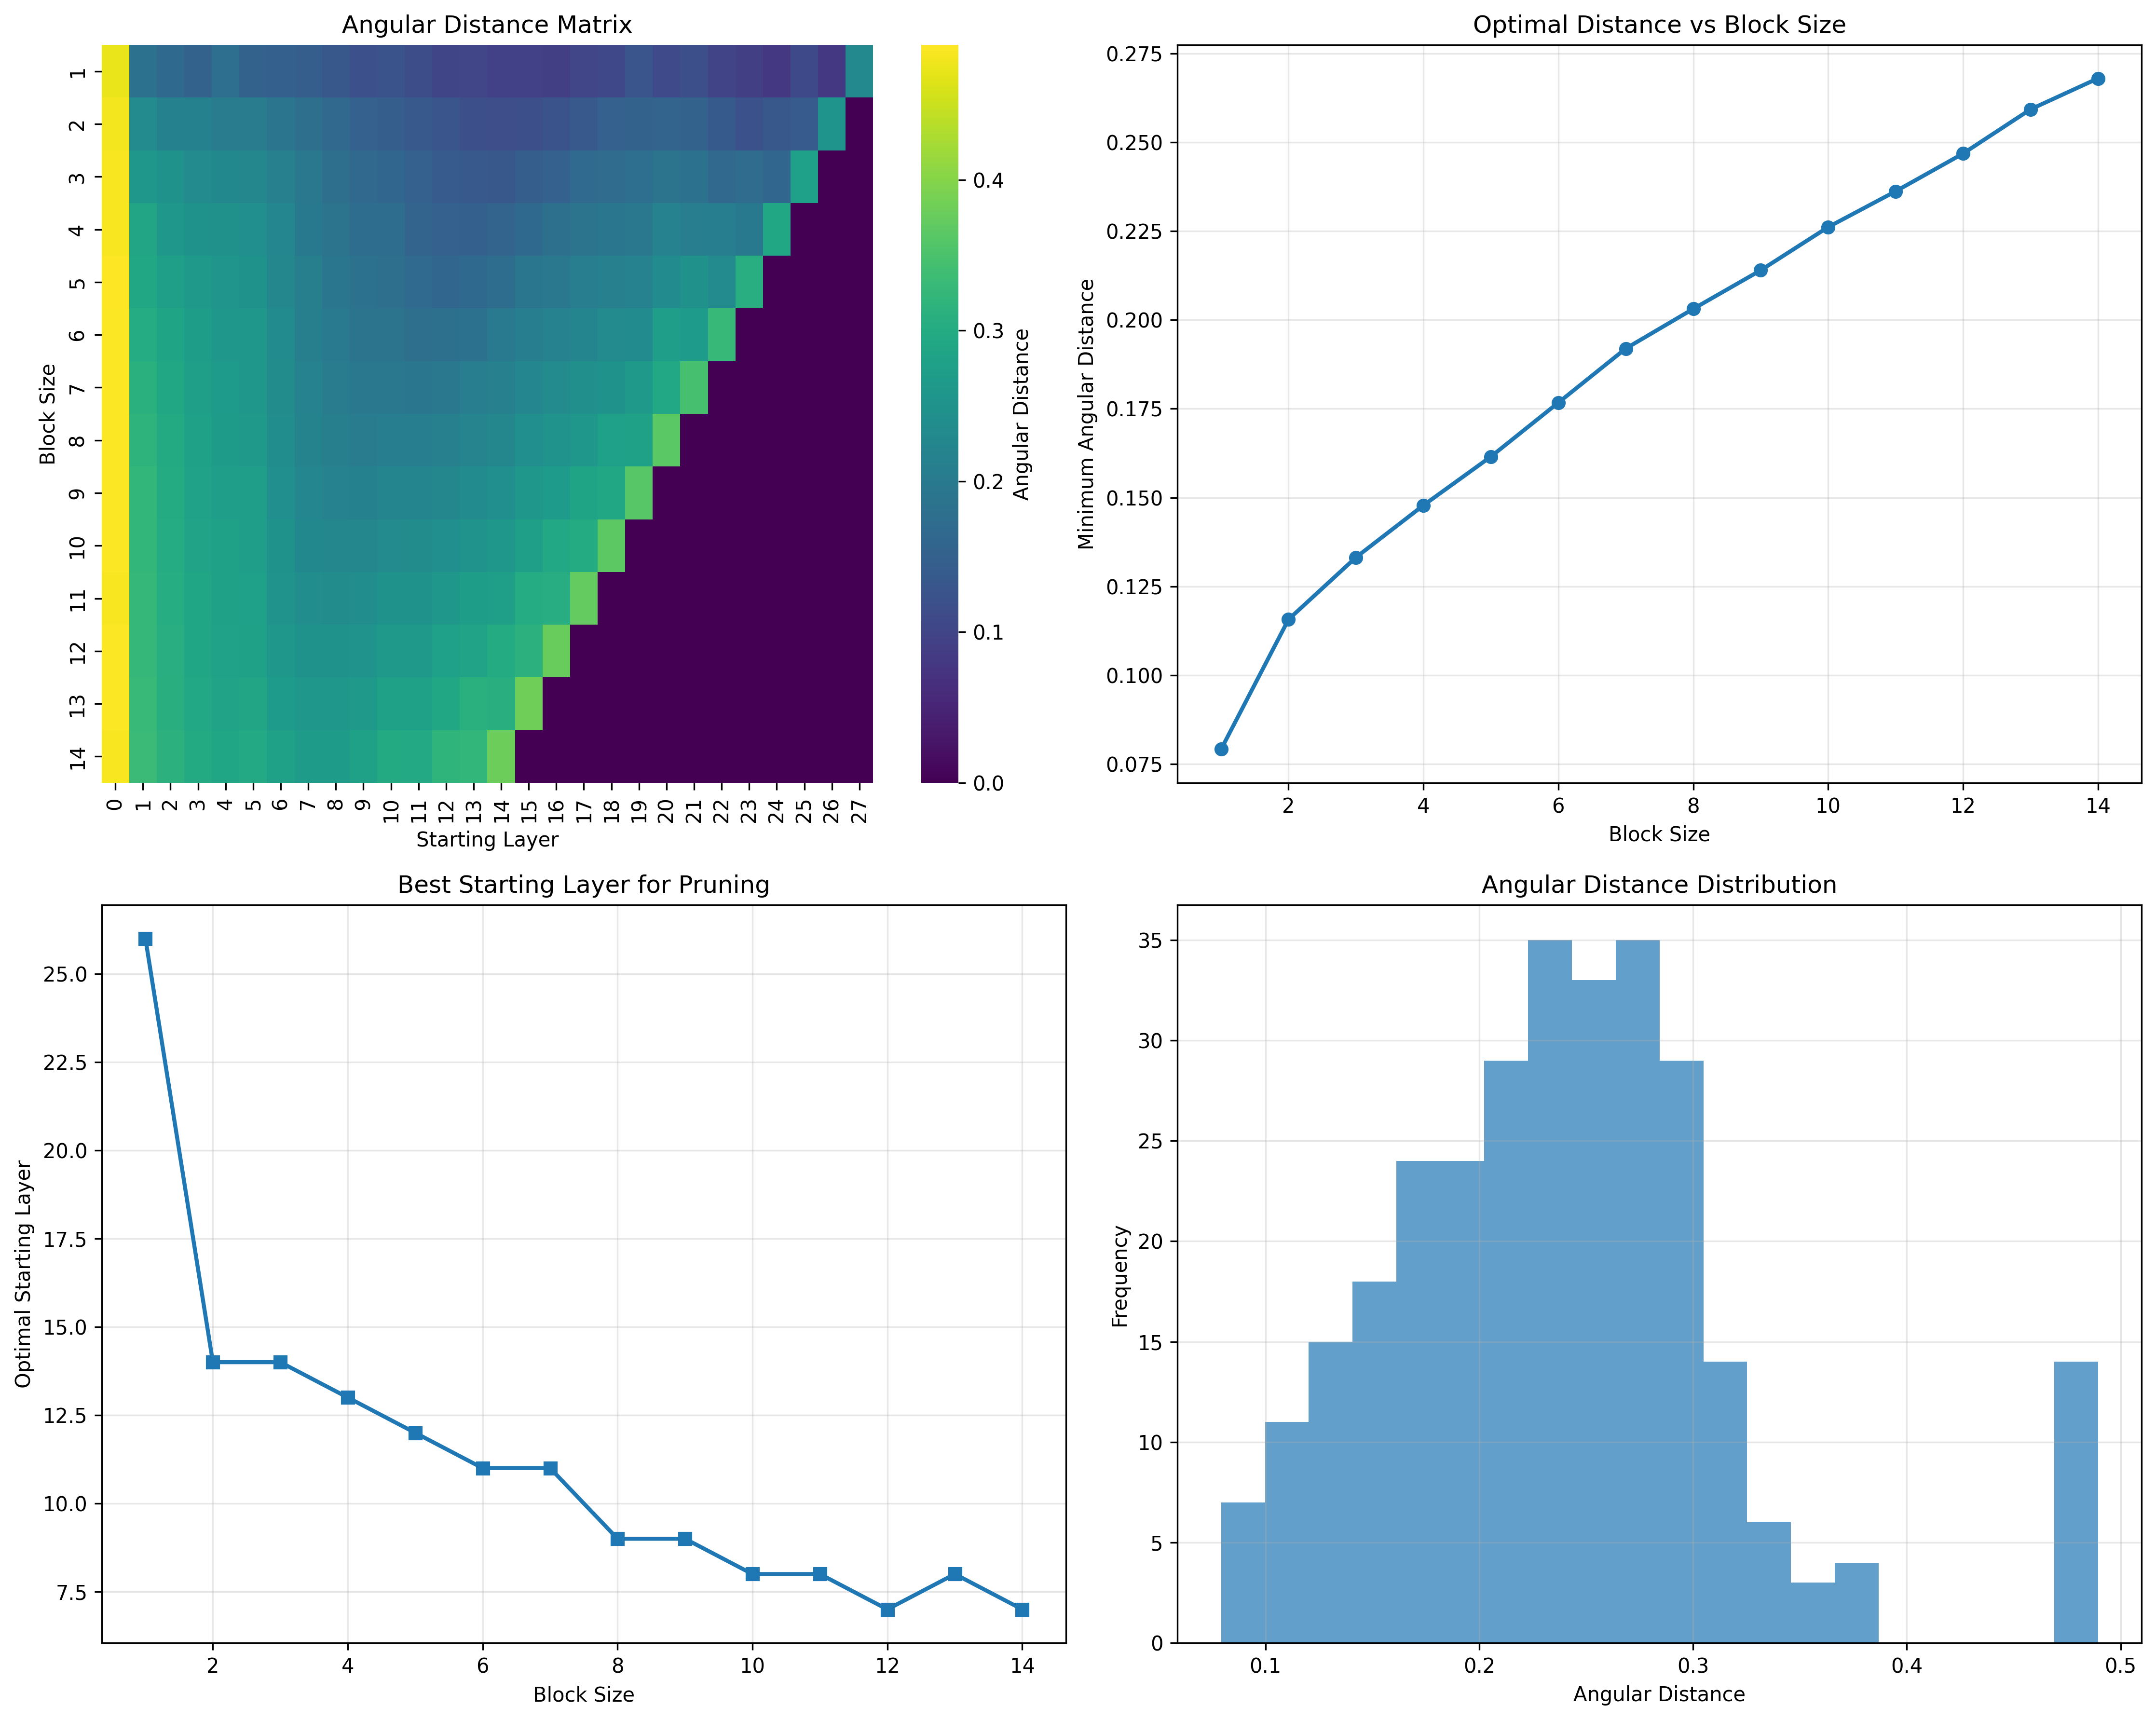

Plots saved to results/qwen-qwen2.5-1.5b_analysis_results.png

6. Generating report...

Qwen/Qwen2.5-1.5B Layer Pruning Analysis Report
Total layers: 28
Minimum angular distance: 0.0792
Maximum angular distance: 0.2679
Average distance: 0.1900

Layer pruning recommendations (inclusive end indices):

10% pruning:
  - Layers to remove: 3
  - Optimal start layer: 14
  - Optimal end layer: 16
  - Angular distance: 0.1332

20% pruning:
  - Layers to remove: 6
  - Optimal start layer: 11
  - Optimal end layer: 16
  - Angular distance: 0.1767

30% pruning:
  - Layers to remove: 8
  - Optimal start layer: 9
  - Optimal end layer: 16
  - Angular distance: 0.2031

40% pruning:
  - Layers to remove: 11
  - Optimal start layer: 8
  - Optimal end layer: 18
  - Angular distance: 0.2362

50% pruning:
  - Layers to remove: 14
  - Optimal start layer: 7
  - Optimal end layer: 20
  - Angular distance: 0.2679

Complete report saved to results/qwen-qwen2.5-1.5b_pruning_report.json

Analysis completed succ

('results/qwen-qwen2.5-1.5b_analysis_results.png',
 'qwen-qwen2.5-1.5b_pruning_report.json',
 {'model_info': {'model_name': 'Qwen/Qwen2.5-1.5B',
   'slug': 'qwen-qwen2.5-1.5b',
   'total_layers': 28,
   'precision': 'bfloat16',
   'quantization': 'none',
   'device': 'cuda',
   'analysis_date': '2025-08-04T20:42:55.217144'},
  'key_statistics': {'min_distance': 0.07919098436832428,
   'max_distance': 0.2679418623447418,
   'mean_distance': 0.18995950849992888,
   'std_distance': 0.05481387127257987},
  'pruning_recommendations': {'10%': {'layers_to_remove': 3,
    'optimal_start_layer': 14,
    'optimal_end_layer': 16,
    'expected_distance': 0.13319028913974762},
   '20%': {'layers_to_remove': 6,
    'optimal_start_layer': 11,
    'optimal_end_layer': 16,
    'expected_distance': 0.17671369016170502},
   '30%': {'layers_to_remove': 8,
    'optimal_start_layer': 9,
    'optimal_end_layer': 16,
    'expected_distance': 0.2030978947877884},
   '40%': {'layers_to_remove': 11,
    'optima

In [5]:
an = LayerPruningAnalyzer(
    model_name="Qwen/Qwen2.5-1.5B",
    dtype="bf16",
    use_8bit=False,
    batch_size=8,
    max_samples=10000,
)
an.run_full_analysis()

**Delete cached objects from previous analysis**

In [6]:
try:
    del an
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

**Qwen2.5-7B:**

Starting Qwen/Qwen2.5-7B layer pruning analysis...

1. Loading model...
Loading model Qwen/Qwen2.5-7B ...


Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.32it/s]


Model loaded with 28 transformer blocks.
GPU memory allocated: 14.20 GB

2. Preparing dataset...
Preparing up to 10000 samples from Wikitext-2 (validation)...
1728 samples prepared (sorted by length).

3. Extracting layer representations...
Extracting layer representations...


Processing: 100%|██████████| 216/216 [01:05<00:00,  3.28it/s]


Extracted representations for 29 layers (including embeddings).

4. Analyzing layer similarities...
Analyzing layer similarities for blocks up to size 14...


Block sizes: 100%|██████████| 14/14 [00:01<00:00,  7.03it/s]


Layer similarity analysis completed.

5. Visualizing results...


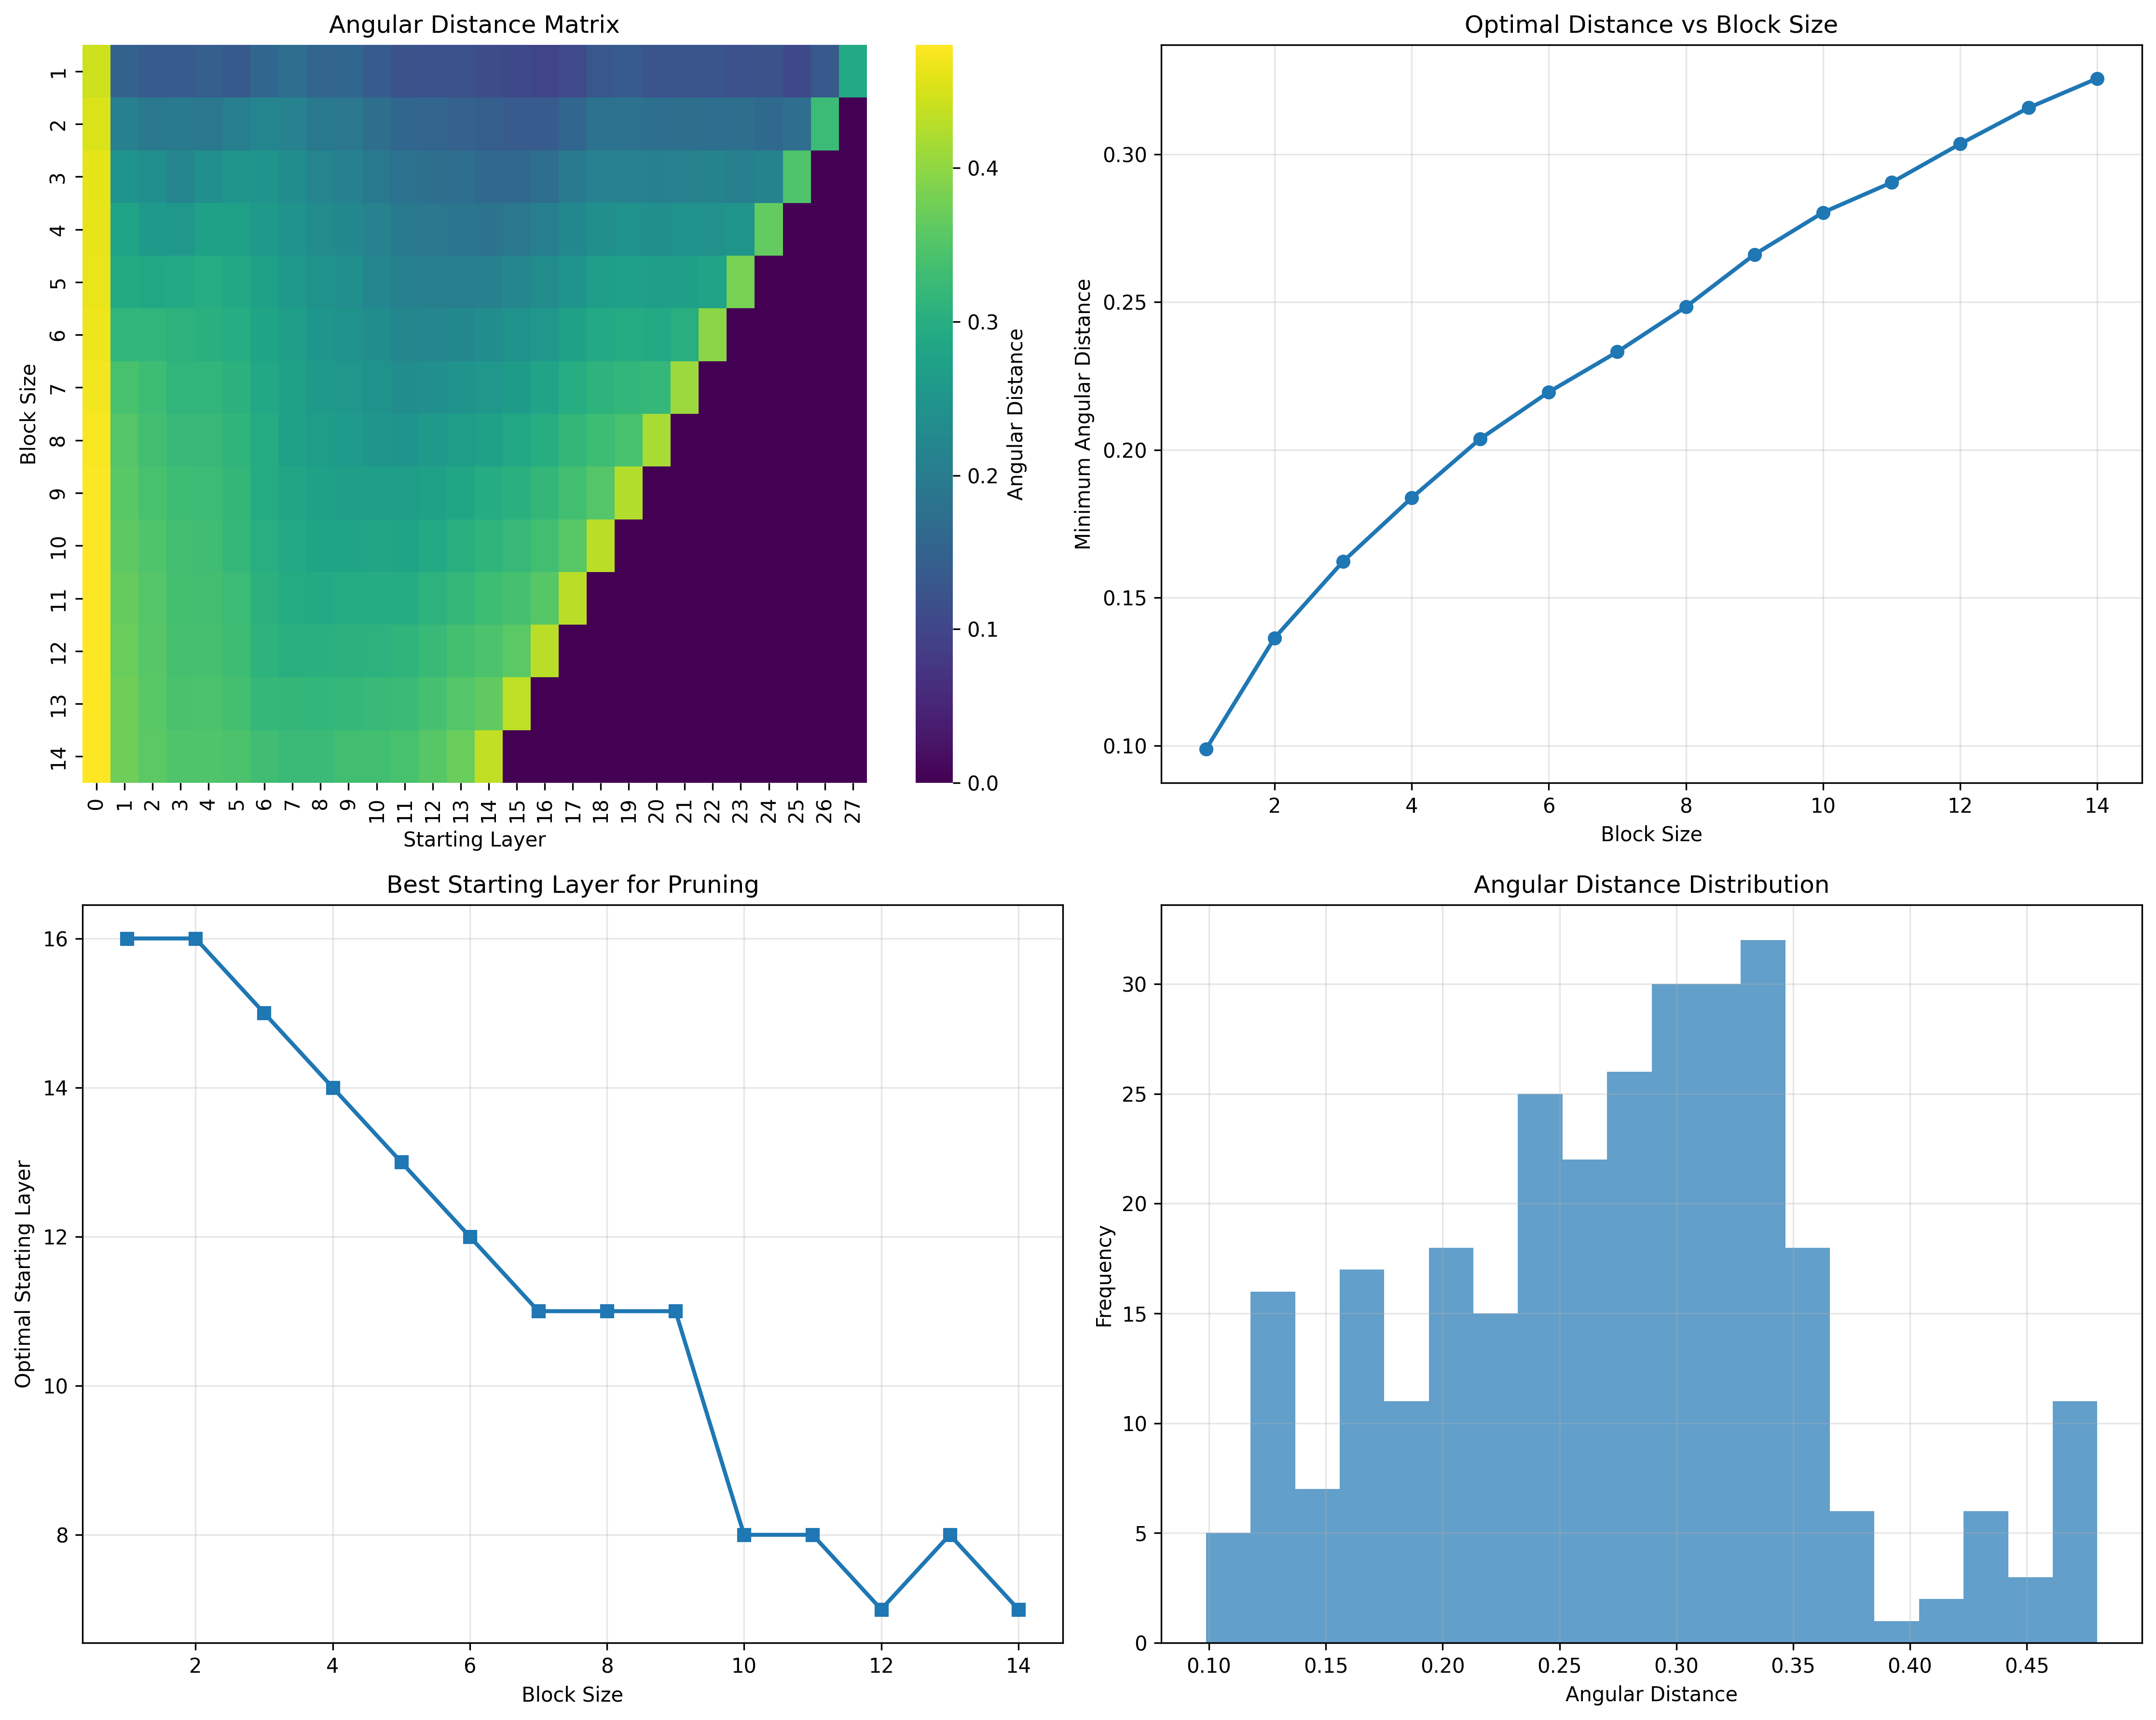

Plots saved to results/qwen-qwen2.5-7b_analysis_results.png

6. Generating report...

Qwen/Qwen2.5-7B Layer Pruning Analysis Report
Total layers: 28
Minimum angular distance: 0.0987
Maximum angular distance: 0.3256
Average distance: 0.2334

Layer pruning recommendations (inclusive end indices):

10% pruning:
  - Layers to remove: 3
  - Optimal start layer: 15
  - Optimal end layer: 17
  - Angular distance: 0.1623

20% pruning:
  - Layers to remove: 6
  - Optimal start layer: 12
  - Optimal end layer: 17
  - Angular distance: 0.2196

30% pruning:
  - Layers to remove: 8
  - Optimal start layer: 11
  - Optimal end layer: 18
  - Angular distance: 0.2484

40% pruning:
  - Layers to remove: 11
  - Optimal start layer: 8
  - Optimal end layer: 18
  - Angular distance: 0.2904

50% pruning:
  - Layers to remove: 14
  - Optimal start layer: 7
  - Optimal end layer: 20
  - Angular distance: 0.3256

Complete report saved to results/qwen-qwen2.5-7b_pruning_report.json

Analysis completed successfu

('results/qwen-qwen2.5-7b_analysis_results.png',
 'qwen-qwen2.5-7b_pruning_report.json',
 {'model_info': {'model_name': 'Qwen/Qwen2.5-7B',
   'slug': 'qwen-qwen2.5-7b',
   'total_layers': 28,
   'precision': 'bfloat16',
   'quantization': 'none',
   'device': 'cuda',
   'analysis_date': '2025-08-04T20:47:19.322928'},
  'key_statistics': {'min_distance': 0.09871178865432739,
   'max_distance': 0.3256317675113678,
   'mean_distance': 0.23339433542319707,
   'std_distance': 0.06713166269284852},
  'pruning_recommendations': {'10%': {'layers_to_remove': 3,
    'optimal_start_layer': 15,
    'optimal_end_layer': 17,
    'expected_distance': 0.1622578650712967},
   '20%': {'layers_to_remove': 6,
    'optimal_start_layer': 12,
    'optimal_end_layer': 17,
    'expected_distance': 0.21956031024456024},
   '30%': {'layers_to_remove': 8,
    'optimal_start_layer': 11,
    'optimal_end_layer': 18,
    'expected_distance': 0.24837525188922882},
   '40%': {'layers_to_remove': 11,
    'optimal_start

In [7]:
an = LayerPruningAnalyzer(
    model_name="Qwen/Qwen2.5-7B",
    dtype="bf16",
    use_8bit=False,
    batch_size=8,
    max_samples=10000,
)
an.run_full_analysis()

In [12]:
try:
    del an
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

Starting Qwen/Qwen3-8B layer pruning analysis...

1. Loading model...
Loading model Qwen/Qwen3-8B ...


Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


Model loaded with 36 transformer blocks.
GPU memory allocated: 15.27 GB

2. Preparing dataset...
Preparing up to 10000 samples from Wikitext-2 (validation)...
1728 samples prepared (sorted by length).

3. Extracting layer representations...
Extracting layer representations...


Processing: 100%|██████████| 216/216 [01:13<00:00,  2.93it/s]


Extracted representations for 37 layers (including embeddings).

4. Analyzing layer similarities...
Analyzing layer similarities for blocks up to size 16...


Block sizes: 100%|██████████| 16/16 [00:04<00:00,  3.73it/s]


Layer similarity analysis completed.

5. Visualizing results...


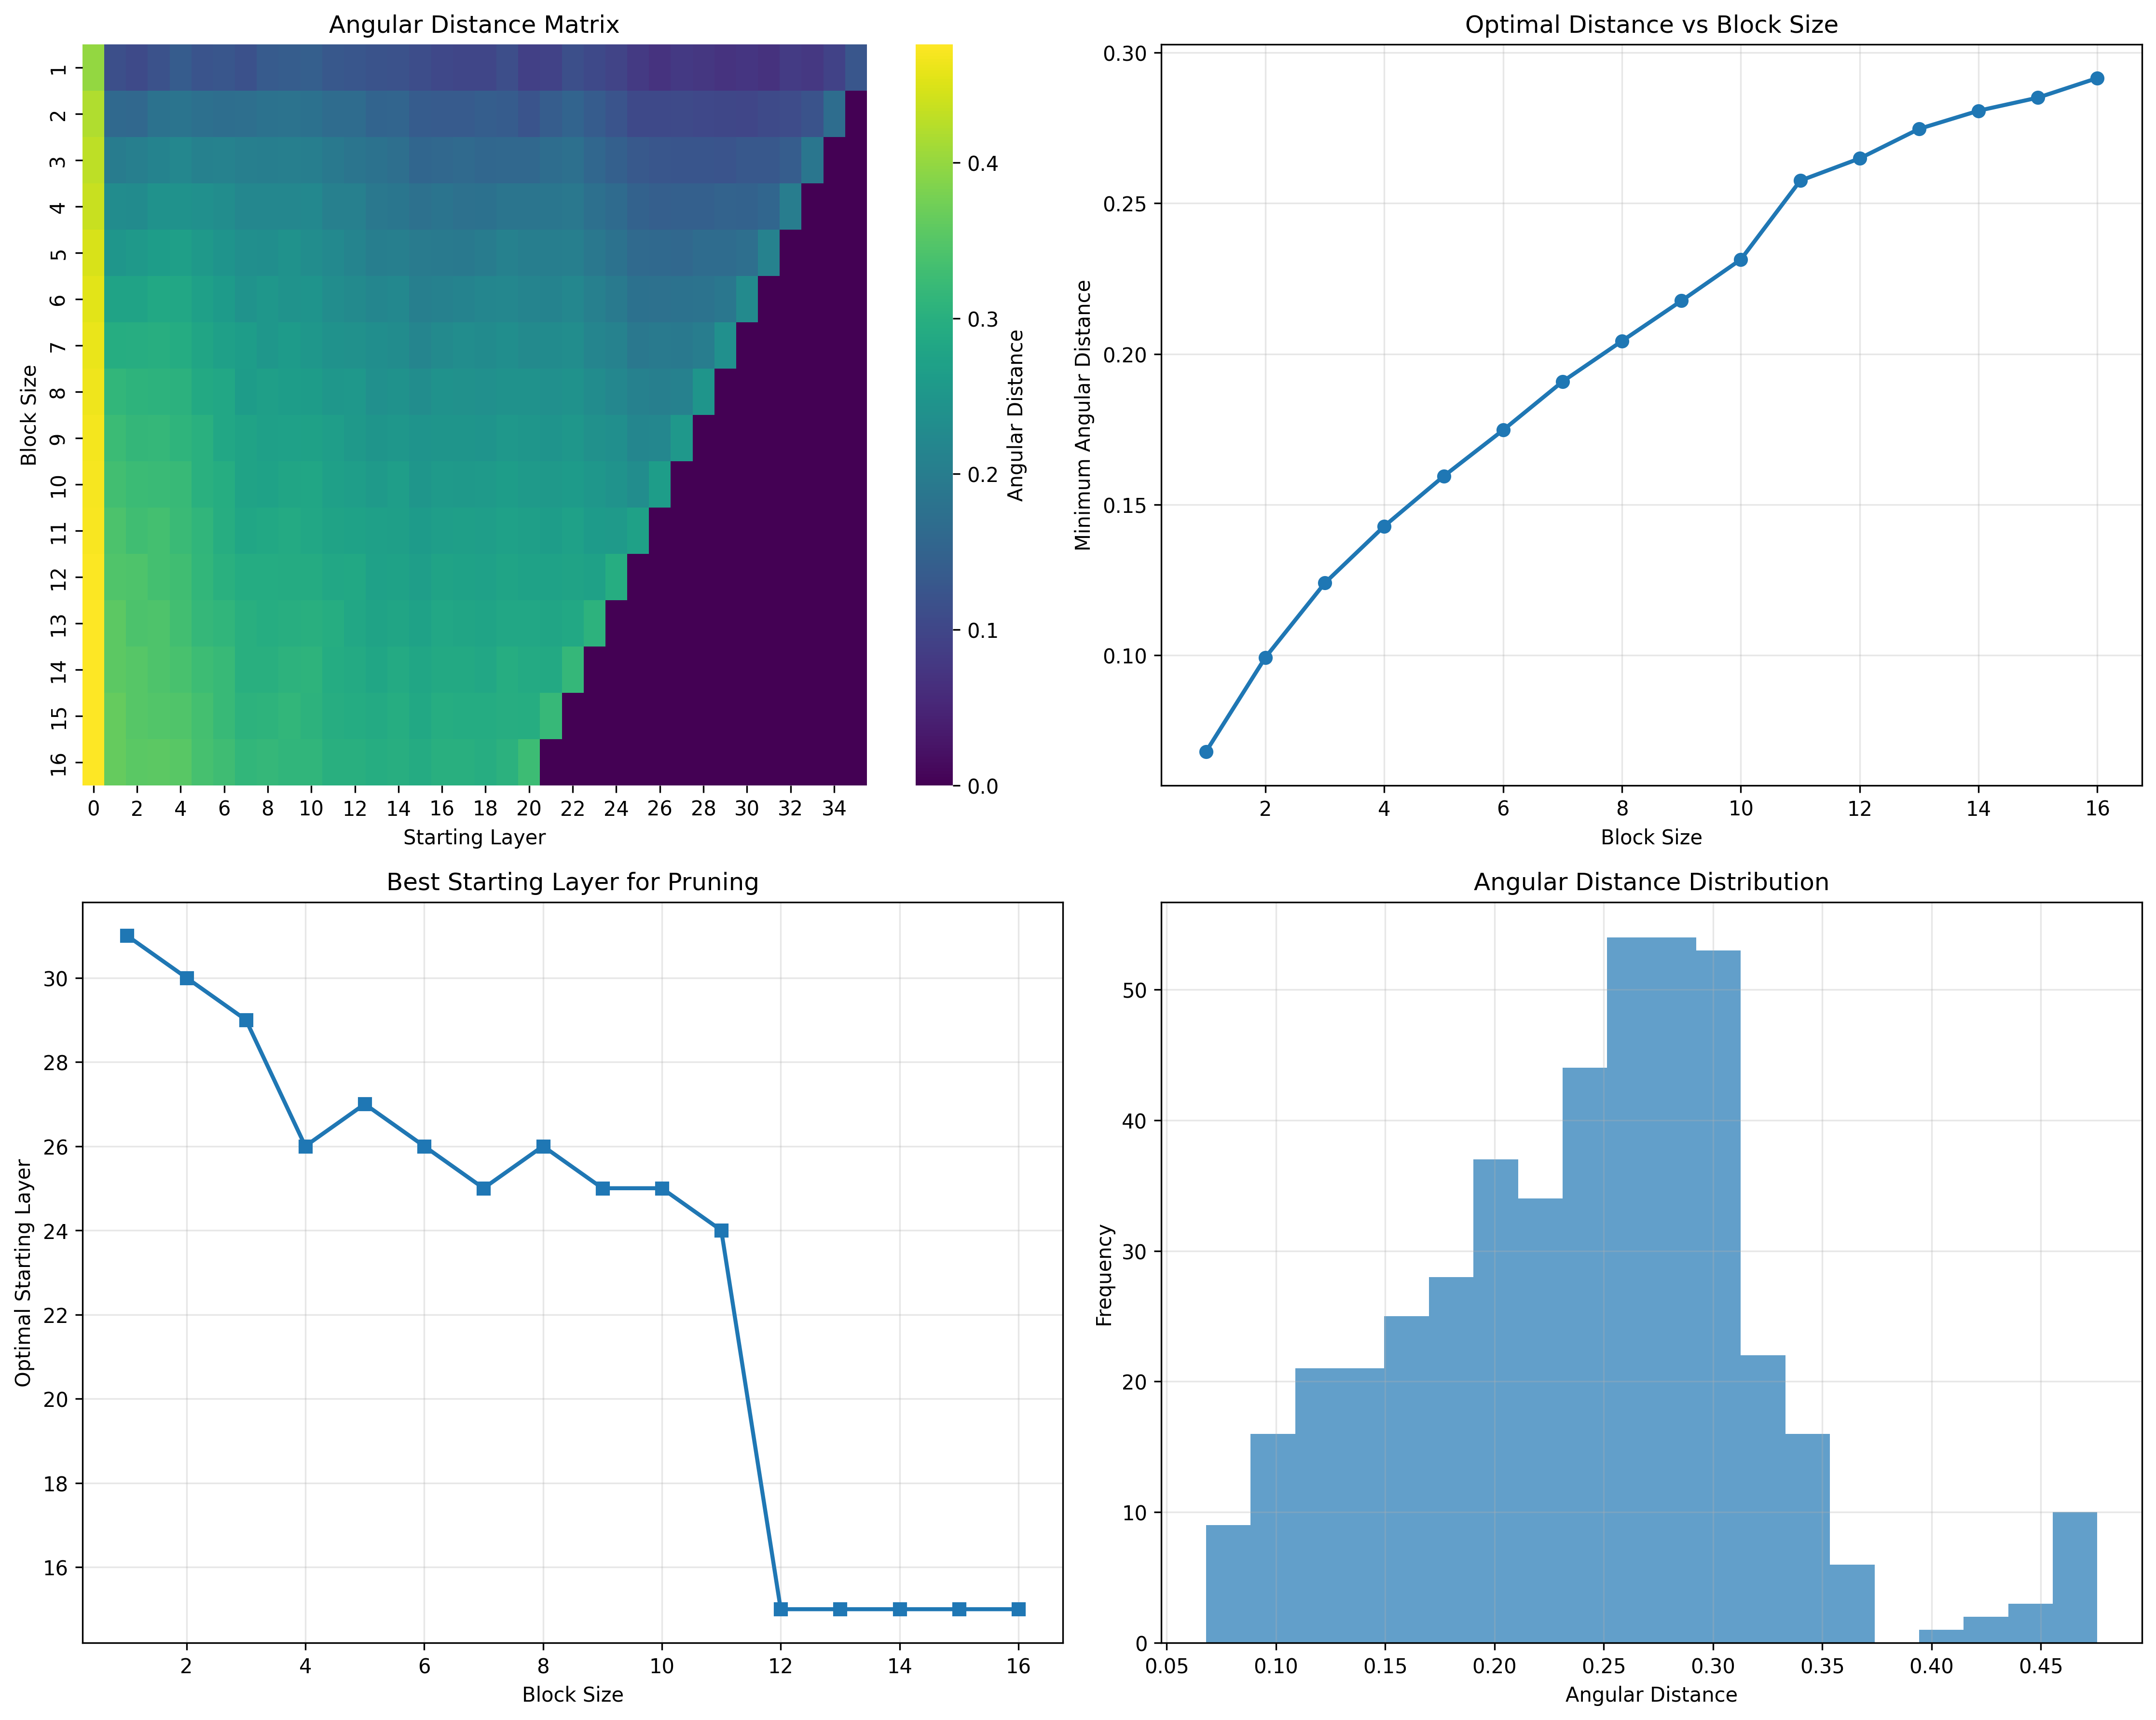

Plots saved to results/qwen-qwen3-8b_analysis_results.png

6. Generating report...

Qwen/Qwen3-8B Layer Pruning Analysis Report
Total layers: 36
Minimum angular distance: 0.0680
Maximum angular distance: 0.2916
Average distance: 0.2042

Layer pruning recommendations (inclusive end indices):

10% pruning:
  - Layers to remove: 4
  - Optimal start layer: 26
  - Optimal end layer: 29
  - Angular distance: 0.1429

20% pruning:
  - Layers to remove: 7
  - Optimal start layer: 25
  - Optimal end layer: 31
  - Angular distance: 0.1908

30% pruning:
  - Layers to remove: 11
  - Optimal start layer: 24
  - Optimal end layer: 34
  - Angular distance: 0.2575

40% pruning:
  - Layers to remove: 14
  - Optimal start layer: 15
  - Optimal end layer: 28
  - Angular distance: 0.2807

Complete report saved to results/qwen-qwen3-8b_pruning_report.json

Analysis completed successfully!
Generated files:
- results/qwen-qwen3-8b_analysis_results.png (visualization plots)
- qwen-qwen3-8b_pruning_report.json 

('results/qwen-qwen3-8b_analysis_results.png',
 'qwen-qwen3-8b_pruning_report.json',
 {'model_info': {'model_name': 'Qwen/Qwen3-8B',
   'slug': 'qwen-qwen3-8b',
   'total_layers': 36,
   'precision': 'bfloat16',
   'quantization': 'none',
   'device': 'cuda',
   'analysis_date': '2025-08-04T22:33:09.813044'},
  'key_statistics': {'min_distance': 0.06802404671907425,
   'max_distance': 0.29158514738082886,
   'mean_distance': 0.20419690059497952,
   'std_distance': 0.06857949332340046},
  'pruning_recommendations': {'10%': {'layers_to_remove': 4,
    'optimal_start_layer': 26,
    'optimal_end_layer': 29,
    'expected_distance': 0.1428646445274353},
   '20%': {'layers_to_remove': 7,
    'optimal_start_layer': 25,
    'optimal_end_layer': 31,
    'expected_distance': 0.19084931910037994},
   '30%': {'layers_to_remove': 11,
    'optimal_start_layer': 24,
    'optimal_end_layer': 34,
    'expected_distance': 0.25753360986709595},
   '40%': {'layers_to_remove': 14,
    'optimal_start_layer

In [13]:
an = LayerPruningAnalyzer(
    model_name="Qwen/Qwen3-8B",
    dtype="bf16",
    use_8bit=False,
    batch_size=8,
    max_samples=10000,
)
an.run_full_analysis()

In [14]:
try:
    del an
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

Starting meta-llama/Llama-3.1-8B layer pruning analysis...

1. Loading model...
Loading model meta-llama/Llama-3.1-8B ...


Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.16it/s]


Model loaded with 32 transformer blocks.
GPU memory allocated: 14.97 GB

2. Preparing dataset...
Preparing up to 10000 samples from Wikitext-2 (validation)...
1728 samples prepared (sorted by length).

3. Extracting layer representations...
Extracting layer representations...


Processing: 100%|██████████| 216/216 [01:09<00:00,  3.12it/s]


Extracted representations for 33 layers (including embeddings).

4. Analyzing layer similarities...
Analyzing layer similarities for blocks up to size 16...


Block sizes: 100%|██████████| 16/16 [00:02<00:00,  5.43it/s]


Layer similarity analysis completed.

5. Visualizing results...


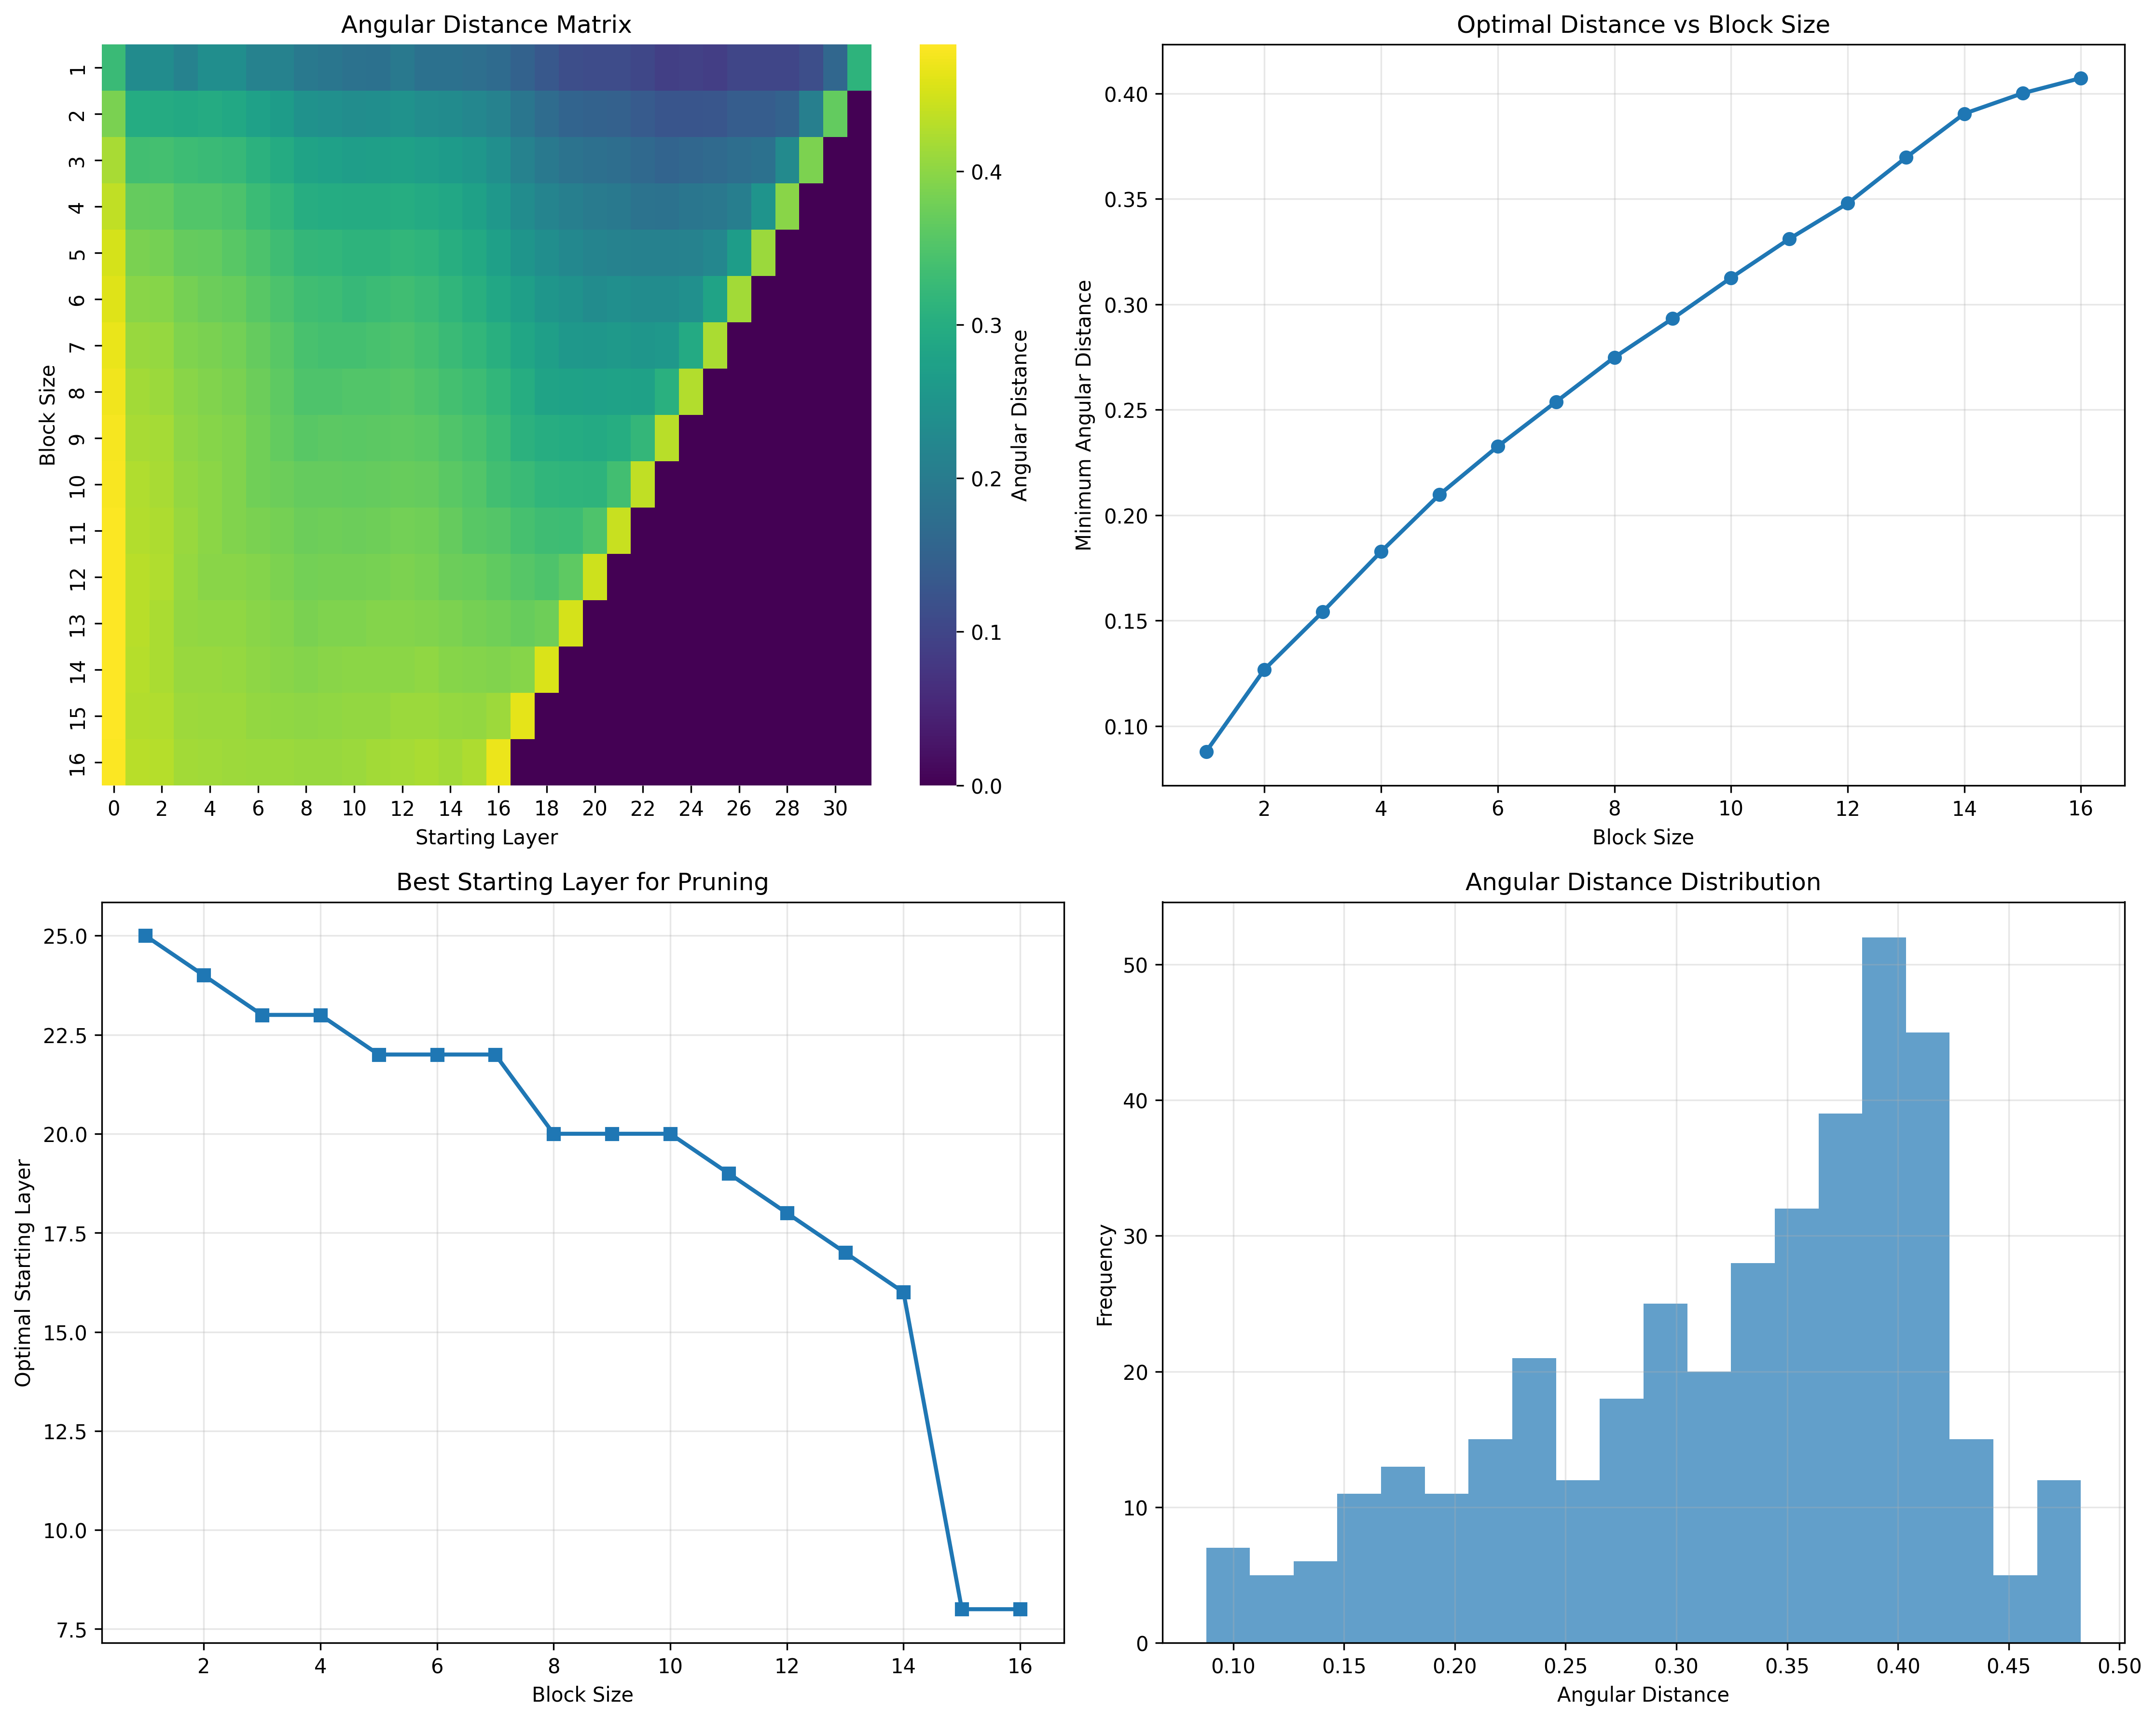

Plots saved to results/meta-llama-llama-3.1-8b_analysis_results.png

6. Generating report...

meta-llama/Llama-3.1-8B Layer Pruning Analysis Report
Total layers: 32
Minimum angular distance: 0.0878
Maximum angular distance: 0.4073
Average distance: 0.2734

Layer pruning recommendations (inclusive end indices):

10% pruning:
  - Layers to remove: 3
  - Optimal start layer: 23
  - Optimal end layer: 25
  - Angular distance: 0.1541

20% pruning:
  - Layers to remove: 6
  - Optimal start layer: 22
  - Optimal end layer: 27
  - Angular distance: 0.2326

30% pruning:
  - Layers to remove: 10
  - Optimal start layer: 20
  - Optimal end layer: 29
  - Angular distance: 0.3125

40% pruning:
  - Layers to remove: 13
  - Optimal start layer: 17
  - Optimal end layer: 29
  - Angular distance: 0.3696

50% pruning:
  - Layers to remove: 16
  - Optimal start layer: 8
  - Optimal end layer: 23
  - Angular distance: 0.4073

Complete report saved to results/meta-llama-llama-3.1-8b_pruning_report.json

An

('results/meta-llama-llama-3.1-8b_analysis_results.png',
 'meta-llama-llama-3.1-8b_pruning_report.json',
 {'model_info': {'model_name': 'meta-llama/Llama-3.1-8B',
   'slug': 'meta-llama-llama-3.1-8b',
   'total_layers': 32,
   'precision': 'bfloat16',
   'quantization': 'none',
   'device': 'cuda',
   'analysis_date': '2025-08-04T22:35:02.540230'},
  'key_statistics': {'min_distance': 0.0877886712551117,
   'max_distance': 0.40727779269218445,
   'mean_distance': 0.2733788788318634,
   'std_distance': 0.09754045757887346},
  'pruning_recommendations': {'10%': {'layers_to_remove': 3,
    'optimal_start_layer': 23,
    'optimal_end_layer': 25,
    'expected_distance': 0.15410426259040833},
   '20%': {'layers_to_remove': 6,
    'optimal_start_layer': 22,
    'optimal_end_layer': 27,
    'expected_distance': 0.23255956172943115},
   '30%': {'layers_to_remove': 10,
    'optimal_start_layer': 20,
    'optimal_end_layer': 29,
    'expected_distance': 0.31253206729888916},
   '40%': {'layers_t

In [15]:
an = LayerPruningAnalyzer(
    model_name="meta-llama/Llama-3.1-8B",
    dtype="bf16",
    use_8bit=False,
    batch_size=8,
    max_samples=10000,
)
an.run_full_analysis()